In [4]:
# Setup & imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import sys
sys.path.append("../src")

from visualization import *
print("Setup working ✅")

Setup working ✅


In [5]:
# Extract and test the dataset

df = pd.read_csv("../data/HDFS.log_structured.csv")

df.head()

,LineId,Date,Time,Pid,Level,Component,Content,EventId,EventTemplate
0,1,81109,203615,148,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...,E10,PacketResponder <*> for block blk_<*> terminating
1,2,81109,203807,222,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487...,E10,PacketResponder <*> for block blk_<*> terminating
2,3,81109,204005,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...
3,4,81109,204015,308,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_82291938032499...,E10,PacketResponder <*> for block blk_<*> terminating
4,5,81109,204106,329,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368...,E10,PacketResponder <*> for block blk_<*> terminating


In [6]:
# Basic Info

print("Shape:", df.shape)
print("\nColumns:", df.columns)

df.info()

Shape: (2000, 9)

Columns: Index(['LineId', 'Date', 'Time', 'Pid', 'Level', 'Component', 'Content',
       'EventId', 'EventTemplate'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   LineId         2000 non-null   int64 
 1   Date           2000 non-null   int64 
 2   Time           2000 non-null   int64 
 3   Pid            2000 non-null   int64 
 4   Level          2000 non-null   object
 5   Component      2000 non-null   object
 6   Content        2000 non-null   object
 7   EventId        2000 non-null   object
 8   EventTemplate  2000 non-null   object
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


In [7]:
# Missing values

df.isnull().sum()

LineId           0
Date             0
Time             0
Pid              0
Level            0
Component        0
Content          0
EventId          0
EventTemplate    0
dtype: int64

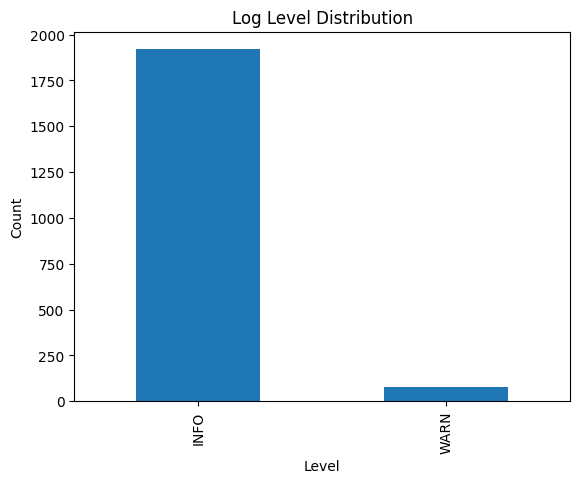

In [8]:
# Log level distribution

plot_log_level_distribution(df)


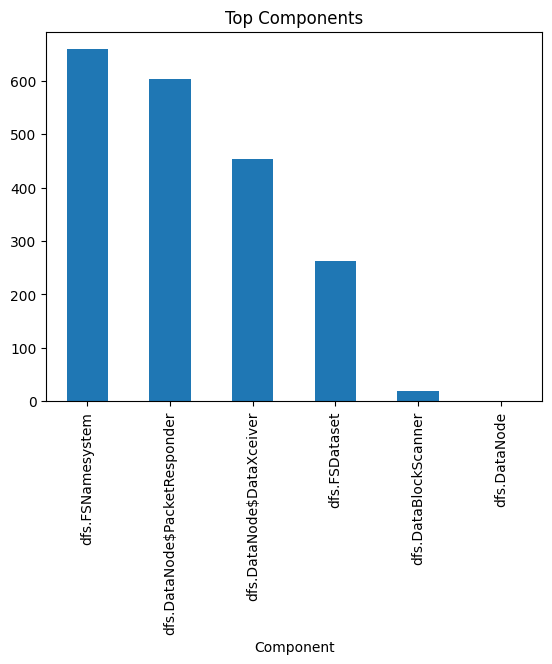

In [9]:
# Component distribution (top 10)
plot_top_components(df)


In [10]:
# Feature Preparation

# Message length
df['msg_length'] = df['Content'].apply(len)

# Time → Hour extraction
df['Time'] = df['Time'].astype(str).str.zfill(6)
df['Hour'] = df['Time'].str[:2].astype(int)

print("Feature columns created ✅")

Feature columns created ✅


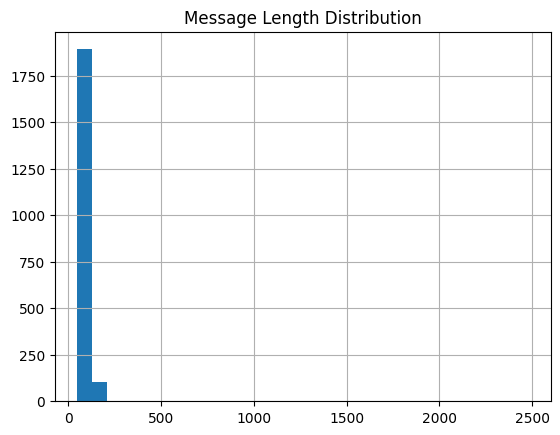

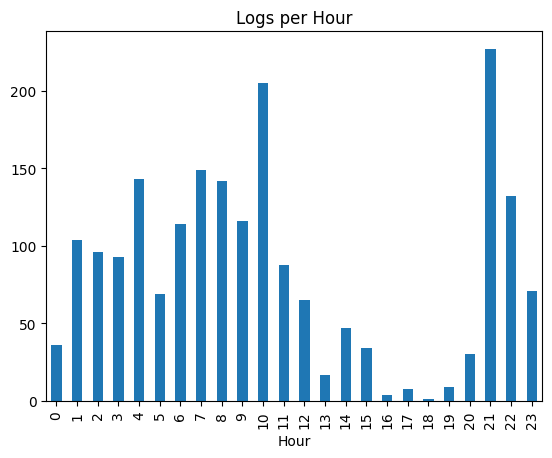

In [11]:
# Time analysis (basic)

plot_message_length(df)
plot_logs_per_hour(df)


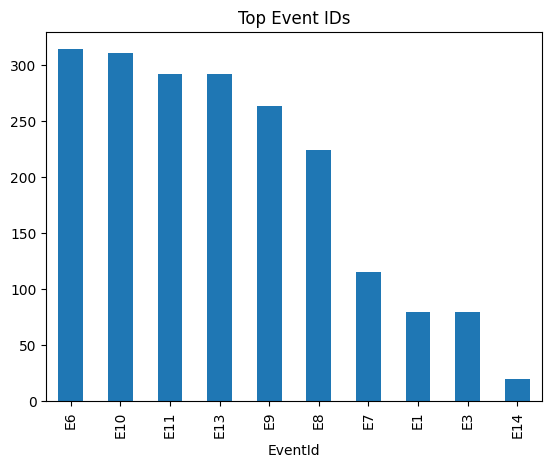

In [12]:
# EventId Distribution

plot_eventid_distribution(df)


In [13]:
# Encode categorical features

from sklearn.preprocessing import LabelEncoder

le_level = LabelEncoder()
le_component = LabelEncoder()
le_event = LabelEncoder()

df['Level_enc'] = le_level.fit_transform(df['Level'])
df['Component_enc'] = le_component.fit_transform(df['Component'])
df['EventId_enc'] = le_event.fit_transform(df['EventId'])

In [14]:
# Select basic numerical features

numeric_features = df[['msg_length', 'Hour', 'Level_enc', 'Component_enc', 'EventId_enc']]

In [15]:
# Convert text → TF-IDF

tfidf = TfidfVectorizer(max_features=100)  # keep small for performance
X_text = tfidf.fit_transform(df['Content'])

In [16]:
# Combine all features

X = hstack([X_text, numeric_features])

In [17]:
# Create labels (for supervised model)

df['Label'] = df['Content'].apply(
    lambda x: 1 if any(word in x.lower() for word in ['error', 'fail', 'exception', 'warn']) else 0
)

y = df['Label']

In [18]:
# Check final shapes

print("Feature shape:", X.shape)
print("Label distribution:\n", y.value_counts())

Feature shape: (2000, 105)
Label distribution:
 Label
0    1920
1      80
Name: count, dtype: int64


In [19]:
# Train Isolation Forest

from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.05,  # ~5% anomalies
    random_state=42
)

iso_model.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [20]:
# Predict anomalies

iso_preds = iso_model.predict(X)

In [21]:
# Convert output

iso_preds = [1 if x == -1 else 0 for x in iso_preds]

In [22]:
# Check results

print("Predicted anomalies:\n", pd.Series(iso_preds).value_counts())

Predicted anomalies:
 0    1902
1      98
Name: count, dtype: int64


In [23]:
# Evaluation using labels — for comparison
print("Isolation Forest Classification Report: \n")
print(classification_report(y, iso_preds))


Isolation Forest Classification Report: 

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1920
           1       0.81      0.99      0.89        80

    accuracy                           0.99      2000
   macro avg       0.90      0.99      0.94      2000
weighted avg       0.99      0.99      0.99      2000



In [24]:
# Confusion Matrix

cm = confusion_matrix(y, iso_preds)
print(cm)

[[1901   19]
 [   1   79]]


In [25]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# Train Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
# Predict

rf_preds = rf_model.predict(X_test)

In [28]:
# Evaluate
print("Random Forest Classification Report: \n")
print(classification_report(y_test, rf_preds))

Random Forest Classification Report: 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       389
           1       1.00      1.00      1.00        11

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [29]:
# Check prediction distribution
print("Predicted Anomalies")
print(pd.Series(rf_preds).value_counts())

Predicted Anomalies
0    389
1     11
Name: count, dtype: int64


In [30]:
# Confusion matrix 

cm = confusion_matrix(y_test, rf_preds)
print(cm)

[[389   0]
 [  0  11]]


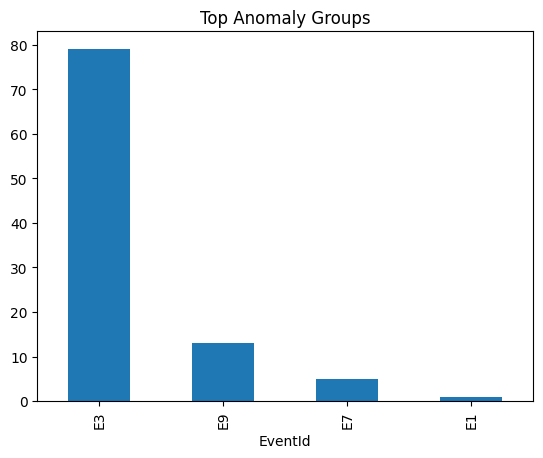

In [31]:
# Group same type of issues together

iso_preds_series = pd.Series(iso_preds)

# Get only anomalies (from Isolation Forest OR labels)
anomaly_df = df[iso_preds_series == 1]

# Group by EventId
plot_anomaly_groups(anomaly_df)

In [32]:
print("Total anomalies detected:", len(anomaly_df))
print("Unique incident groups:", anomaly_df['EventId'].nunique())

Total anomalies detected: 98
Unique incident groups: 4
